# Time Series Analysis

Created from `Time Series Analysis.py` — notebook version for interactive exploration and modeling of weekly demand for electronics products using Holt-Winters Exponential Smoothing.

Author: salemt

Notebook outline:
- Load data
- Preprocess & aggregate
- Resample weekly and build time series per product
- Fit Triple Exponential Smoothing models per product
- Evaluate and produce final forecasts
- Visualize results

Assumptions: weekly resampling, seasonal_periods=4 (4-week season) due to partial-year data.

In [1]:
pip install --upgrade statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# %%
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime

# Make plots display inline when running in a notebook environment
%matplotlib inline

In [4]:
# %%
# Load dataset
csv_path = "/Users/salemt/Downloads/Walmart_Cleaned (1).csv"
df = pd.read_csv(csv_path)

# Display basic information
print("Data shape:", df.shape)
print("\nData info:")
print(df.info())

df.head()

Data shape: (5000, 33)

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   product_id              5000 non-null   int64  
 3   product_name            5000 non-null   object 
 4   category                5000 non-null   object 
 5   quantity_sold           5000 non-null   int64  
 6   unit_price              5000 non-null   float64
 7   transaction_date        5000 non-null   object 
 8   store_id                5000 non-null   int64  
 9   store_location          5000 non-null   object 
 10  inventory_level         5000 non-null   int64  
 11  reorder_point           5000 non-null   int64  
 12  reorder_quantity        5000 non-null   int64  
 13  supplier_id             5000 non-null   int64  
 14  suppl

,transaction_id,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,...,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand,unique_store_number,transaction_day,transaction_month,is_weekend,age_group
0,1,2824,843,Fridge,Appliances,3,188.46,2024-03-31 21:46:00,3,"Miami, FL",...,False,Friday,True,172,179,1,Sunday,March,True,18-30
1,2,1409,135,TV,Electronics,4,1912.04,2024-07-28 12:45:00,5,"Dallas, TX",...,False,Monday,True,109,484,2,Sunday,July,True,31-45
2,3,5506,391,Fridge,Appliances,4,1377.75,2024-06-10 04:55:00,1,"Los Angeles, CA",...,False,Tuesday,True,289,416,3,Monday,June,False,60+
3,4,5012,710,Smartphone,Electronics,5,182.31,2024-08-15 01:03:00,5,"Miami, FL",...,True,Sunday,False,174,446,4,Thursday,August,False,46-60
4,5,4657,116,Laptop,Electronics,3,499.28,2024-09-13 00:45:00,6,"Chicago, IL",...,False,Thursday,True,287,469,5,Friday,September,False,60+


In [5]:
# %%
# Preprocess dates & filter Electronics
# preserve original behavior: convert to date (no time component)
df['transaction_date'] = pd.to_datetime(df['transaction_date']).dt.date

df = df.sort_values(by=['transaction_date']).reset_index(drop=True)
electronics = df[df['category'] == 'Electronics']

print("Unique products:", electronics['product_name'].unique())

electronics.head()

Unique products: ['Smartphone' 'Laptop' 'TV' 'Tablet' 'Headphones' 'Camera']


,transaction_id,customer_id,product_id,product_name,category,quantity_sold,unit_price,transaction_date,store_id,store_location,...,holiday_indicator,weekday,stockout_indicator,forecasted_demand,actual_demand,unique_store_number,transaction_day,transaction_month,is_weekend,age_group
1,2795,4705,154,Smartphone,Electronics,5,1275.99,2024-01-01,2,"Los Angeles, CA",...,True,Saturday,True,257,484,19,Monday,January,False,18-30
2,817,8451,462,Laptop,Electronics,1,1219.58,2024-01-01,11,"Los Angeles, CA",...,False,Thursday,False,124,91,37,Monday,January,False,60+
4,4332,9706,401,TV,Electronics,2,954.44,2024-01-01,2,"Dallas, TX",...,False,Saturday,True,319,313,89,Monday,January,False,31-45
5,198,6804,348,TV,Electronics,2,1598.03,2024-01-01,9,"Dallas, TX",...,True,Tuesday,True,116,452,20,Monday,January,False,31-45
6,1952,8849,913,Tablet,Electronics,2,1840.31,2024-01-01,2,"Miami, FL",...,False,Thursday,True,353,499,34,Monday,January,False,46-60


  transaction_date product_name  unique_store_number  actual_demand
0       2024-01-01       Camera                   17            263
1       2024-01-01       Camera                   57             99
2       2024-01-01       Camera                   71            181
3       2024-01-01   Headphones                    1            357
4       2024-01-01   Headphones                   14            153


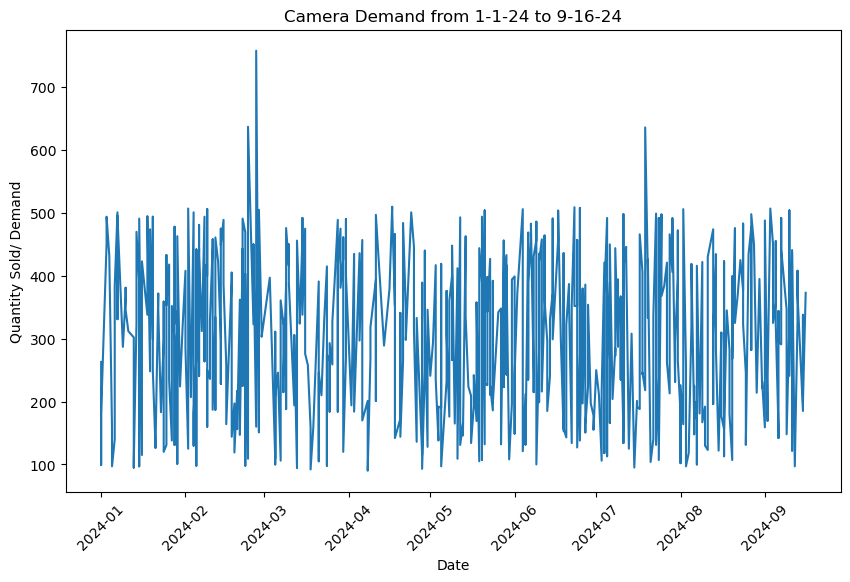

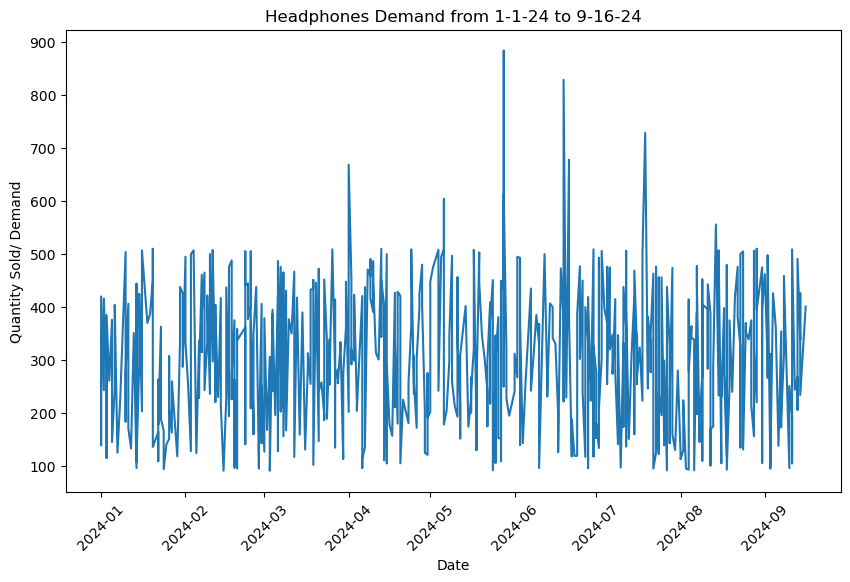

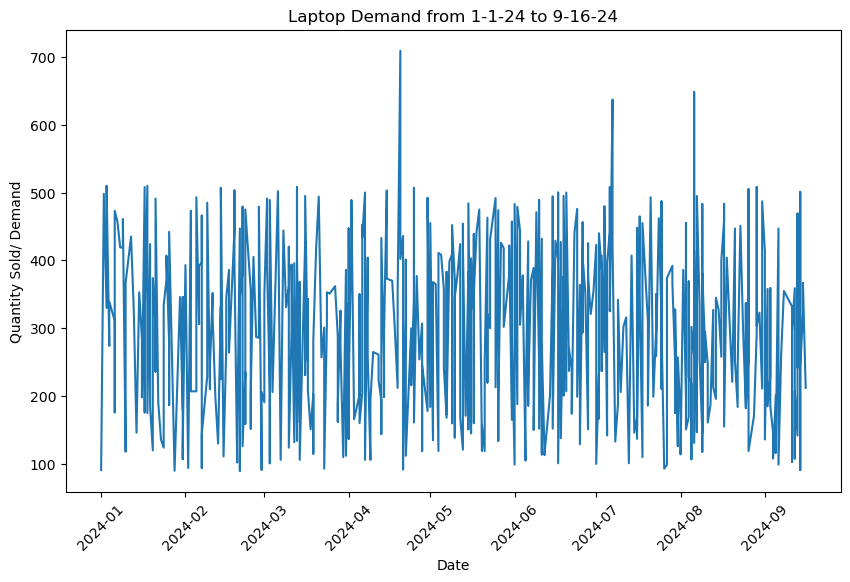

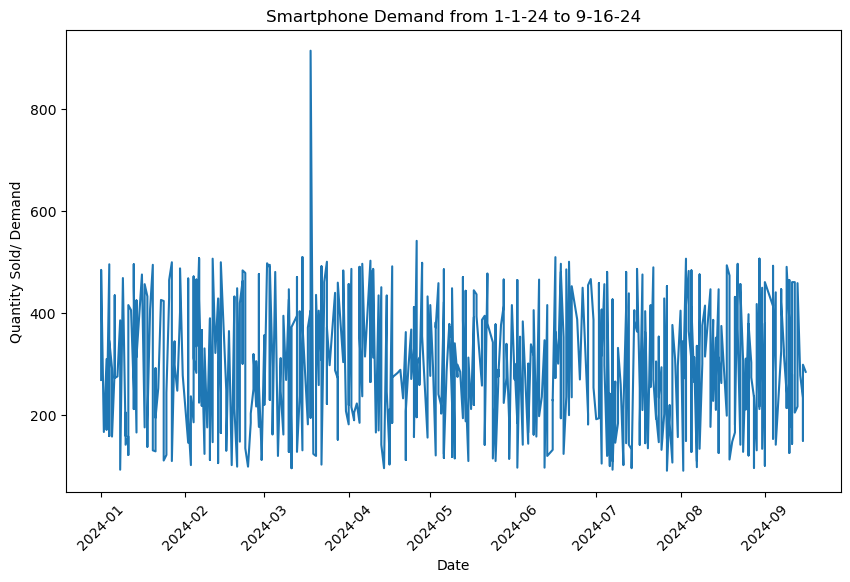

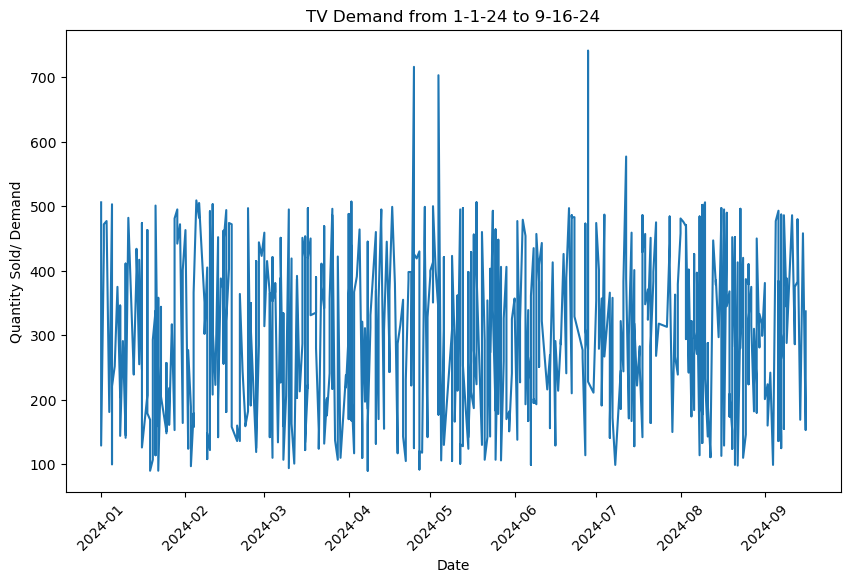

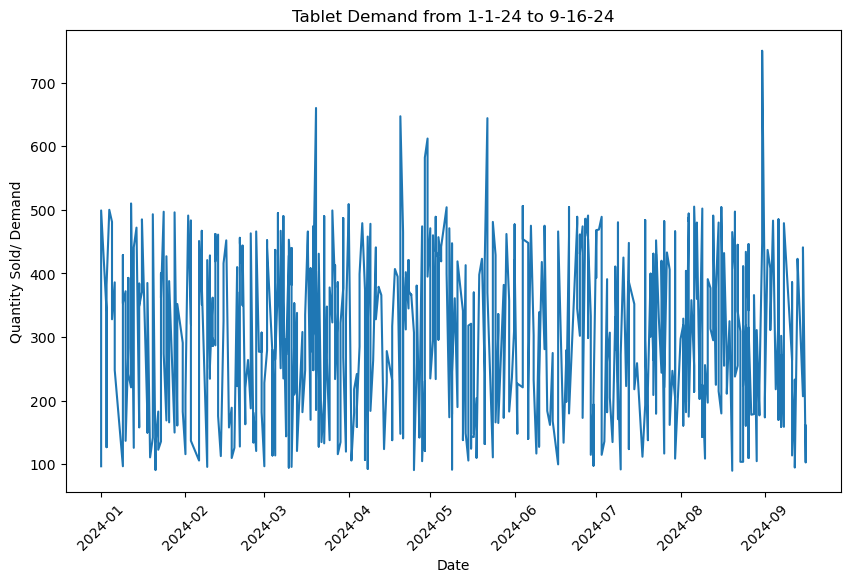

In [6]:
# %%
# Aggregate sales by date & product
df_grouped = electronics.groupby(['transaction_date', 'product_name', 'unique_store_number'])['actual_demand'].sum().reset_index()

# Display a pivot sample
print(df_grouped.head())

# EDA: plot demand time series per product
for product in df_grouped['product_name'].unique():
    product_df = df_grouped[df_grouped['product_name'] == product]
    
    plt.figure(figsize=(10,6))
    plt.plot(product_df['transaction_date'], product_df['actual_demand'])
    plt.title(f"{product} Demand from 1-1-24 to 9-16-24")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("Quantity Sold/ Demand")
    plt.show()


In [7]:
df_grouped.head()

,transaction_date,product_name,unique_store_number,actual_demand
0,2024-01-01,Camera,17,263
1,2024-01-01,Camera,57,99
2,2024-01-01,Camera,71,181
3,2024-01-01,Headphones,1,357
4,2024-01-01,Headphones,14,153


In [8]:
# %%
# Create weekly time series per product (TV)
# TV

tv_data = df_grouped[df_grouped['product_name'] == 'TV']
tv_data = tv_data.sort_values(by=['transaction_date']).reset_index(drop=True)
tv_data['transaction_date'] = pd.to_datetime(tv_data['transaction_date'])

tv_data = tv_data.set_index('transaction_date')
daily_tv_data = tv_data['actual_demand'].resample('D').sum()

# train/test split
train_size_tv = int(len(daily_tv_data) * 0.7)
train_tv = daily_tv_data.iloc[:train_size_tv]
test_tv = daily_tv_data.iloc[train_size_tv:]

# Triple Exponential Smoothing
model_triple_tv = ExponentialSmoothing(train_tv, trend='add', seasonal='add', seasonal_periods=7)
fitted_model_tv = model_triple_tv.fit()

pred_triple_model_tv = fitted_model_tv.forecast(len(test_tv))

print('TV daily series length:', len(daily_tv_data))
daily_tv_data.head()

TV daily series length: 260


transaction_date
2024-01-01    1775
2024-01-02     907
2024-01-03     477
2024-01-04     181
2024-01-05    1871
Freq: D, Name: actual_demand, dtype: int64

In [9]:
# %%
# Tablet

tablet_data = df_grouped[df_grouped['product_name'] == 'Tablet']
tablet_data = tablet_data.sort_values(by=['transaction_date']).reset_index(drop=True)
tablet_data['transaction_date'] = pd.to_datetime(tablet_data['transaction_date'])

tablet_data = tablet_data.set_index('transaction_date')
daily_tablet_data = tablet_data['actual_demand'].resample('D').sum()

train_size_tab = int(len(daily_tablet_data) * 0.7)
train_tab = daily_tablet_data.iloc[:train_size_tab]
test_tab = daily_tablet_data.iloc[train_size_tab:]

model_triple_tab = ExponentialSmoothing(train_tab, trend='add', seasonal='add', seasonal_periods=7)
fitted_model_tab = model_triple_tab.fit()

pred_triple_model_tab = fitted_model_tab.forecast(len(test_tab))

print('Tablet daily series length:', len(daily_tablet_data))
daily_tablet_data.head()

Tablet daily series length: 260


transaction_date
2024-01-01    1093
2024-01-02       0
2024-01-03    1708
2024-01-04     500
2024-01-05     809
Freq: D, Name: actual_demand, dtype: int64

In [10]:
# %%
# Camera

camera_data = df_grouped[df_grouped['product_name'] == 'Camera']
camera_data = camera_data.sort_values(by=['transaction_date']).reset_index(drop=True)
camera_data['transaction_date'] = pd.to_datetime(camera_data['transaction_date'])

camera_data = camera_data.set_index('transaction_date')
daily_camera_data = camera_data['actual_demand'].resample('D').sum()

train_size_cam = int(len(daily_camera_data) * 0.7)
train_cam = daily_camera_data.iloc[:train_size_cam]
test_cam = daily_camera_data.iloc[train_size_cam:]

model_triple_cam = ExponentialSmoothing(train_cam, trend='add', seasonal='add', seasonal_periods=7)
fitted_model_cam = model_triple_cam.fit()

pred_triple_model_cam = fitted_model_cam.forecast(len(test_cam))

print('Camera daily series length:', len(daily_camera_data))
daily_camera_data.head()

Camera daily series length: 260


transaction_date
2024-01-01    543
2024-01-02      0
2024-01-03    945
2024-01-04    432
2024-01-05    255
Freq: D, Name: actual_demand, dtype: int64

In [11]:
# %%
# Laptop

laptop_data = df_grouped[df_grouped['product_name'] == 'Laptop']
laptop_data = laptop_data.sort_values(by=['transaction_date']).reset_index(drop=True)
laptop_data['transaction_date'] = pd.to_datetime(laptop_data['transaction_date'])

laptop_data = laptop_data.set_index('transaction_date')
daily_laptop_data = laptop_data['actual_demand'].resample('D').sum()

train_size_laptop = int(len(daily_laptop_data) * 0.7)
train_laptop = daily_laptop_data.iloc[:train_size_laptop]
test_laptop = daily_laptop_data.iloc[train_size_laptop:]

model_triple_laptop = ExponentialSmoothing(train_laptop, trend='add', seasonal='add', seasonal_periods=7)
fitted_model_laptop = model_triple_laptop.fit()

pred_triple_model_laptop = fitted_model_laptop.forecast(len(test_laptop))

print('Laptop daily series length:', len(daily_laptop_data))
daily_laptop_data.head()

Laptop daily series length: 260


transaction_date
2024-01-01     91
2024-01-02    498
2024-01-03    840
2024-01-04    950
2024-01-05      0
Freq: D, Name: actual_demand, dtype: int64

In [12]:
# %%
# Headphones

headphones_data = df_grouped[df_grouped['product_name'] == 'Headphones']
headphones_data = headphones_data.sort_values(by=['transaction_date']).reset_index(drop=True)
headphones_data['transaction_date'] = pd.to_datetime(headphones_data['transaction_date'])

headphones_data = headphones_data.set_index('transaction_date')
daily_headphones_data = headphones_data['actual_demand'].resample('D').sum()

train_size_headphones = int(len(daily_headphones_data) * 0.7)
train_headphones = daily_headphones_data.iloc[:train_size_headphones]
test_headphones = daily_headphones_data.iloc[train_size_headphones:]

model_triple_headphones = ExponentialSmoothing(train_headphones, trend='add', seasonal='add', seasonal_periods=7)
fitted_model_headphones = model_triple_headphones.fit()

pred_triple_model_headphones = fitted_model_headphones.forecast(len(test_headphones))

print('Headphones weekly series length:', len(daily_headphones_data))
daily_headphones_data.head()

Headphones weekly series length: 260


transaction_date
2024-01-01    1069
2024-01-02     659
2024-01-03     770
2024-01-04     261
2024-01-05     521
Freq: D, Name: actual_demand, dtype: int64

In [13]:
# %%
# Evaluation metrics
from math import sqrt

mae_tv = mean_absolute_error(test_tv, pred_triple_model_tv)
mae_tab = mean_absolute_error(test_tab, pred_triple_model_tab)
mae_cam = mean_absolute_error(test_cam, pred_triple_model_cam)
mae_lp = mean_absolute_error(test_laptop, pred_triple_model_laptop)
mae_hp = mean_absolute_error(test_headphones, pred_triple_model_headphones)

rmse_tv = sqrt(mean_squared_error(test_tv, pred_triple_model_tv))
rmse_tab = sqrt(mean_squared_error(test_tab, pred_triple_model_tab))
rmse_cam = sqrt(mean_squared_error(test_cam, pred_triple_model_cam))
rmse_lp = sqrt(mean_squared_error(test_laptop, pred_triple_model_laptop))
rmse_hp = sqrt(mean_squared_error(test_headphones, pred_triple_model_headphones))

mape_tv = mean_absolute_percentage_error(test_tv, pred_triple_model_tv)
mape_tab = mean_absolute_percentage_error(test_tab, pred_triple_model_tab)
mape_cam = mean_absolute_percentage_error(test_cam, pred_triple_model_cam)
mape_lp = mean_absolute_percentage_error(test_laptop, pred_triple_model_laptop)
mape_hp = mean_absolute_percentage_error(test_headphones, pred_triple_model_headphones)

model_performance = {
    "TV": {"MAE": mae_tv, "RMSE": rmse_tv, "MAPE": mape_tv},
    "Tablet": {"MAE": mae_tab, "RMSE": rmse_tab, "MAPE": mape_tab},
    "Camera": {"MAE": mae_cam, "RMSE": rmse_cam, "MAPE": mape_cam},
    "Laptop": {"MAE": mae_lp, "RMSE": rmse_lp, "MAPE": mape_lp},
    "Headphones": {"MAE": mae_hp, "RMSE": rmse_hp, "MAPE": mape_hp}}

model_performance_df = pd.DataFrame(model_performance).T
model_performance_df.round(4)

,MAE,RMSE,MAPE
TV,366.2363,484.1348,1.876590e+17
Tablet,402.9564,522.9658,2.335300e+17
Camera,409.5553,491.5956,1.364004e+17
Laptop,415.3328,494.9334,2.474069e+17
Headphones,388.9139,491.6789,1.836826e+17


In [14]:
# %% #### Final Models & Forecasts
final_tv = ExponentialSmoothing(daily_tv_data, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast_tv = final_tv.forecast(21)

final_tablet = ExponentialSmoothing(daily_tablet_data, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast_tablet = final_tablet.forecast(21)

final_camera = ExponentialSmoothing(daily_camera_data, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast_camera = final_camera.forecast(21)

final_laptop = ExponentialSmoothing(daily_laptop_data, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast_laptop = final_laptop.forecast(21)

final_headphones = ExponentialSmoothing(daily_headphones_data, trend='add', seasonal='add', seasonal_periods=7).fit()
forecast_headphones = final_headphones.forecast(21)

forecast_tv = final_tv.forecast(21).reset_index(drop=True)
forecast_camera = final_camera.forecast(21).reset_index(drop=True)
forecast_tablet = final_tablet.forecast(21).reset_index(drop=True)
forecast_laptop = final_laptop.forecast(21).reset_index(drop=True)
forecast_headphones = final_headphones.forecast(21).reset_index(drop=True)

future_dates = pd.date_range(
    start=daily_tv_data.index[-1] + pd.Timedelta(days=1),
    periods=21,
    freq='D'
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Tv": forecast_tv.round(),
    "Camera": forecast_camera.round(),
    "Tablet": forecast_tablet.round(),
    "Laptop": forecast_laptop.round(),
    "Headphones": forecast_headphones.round()
})

forecast_df.to_csv('Time_Series_Analysis.csv', index=False)
forecast_df.head()

,Date,Tv,Camera,Tablet,Laptop,Headphones
0,2024-09-17,695.0,832.0,837.0,562.0,659.0
1,2024-09-18,535.0,975.0,782.0,755.0,767.0
2,2024-09-19,854.0,649.0,716.0,645.0,653.0
3,2024-09-20,765.0,750.0,833.0,612.0,684.0
4,2024-09-21,833.0,674.0,749.0,783.0,701.0


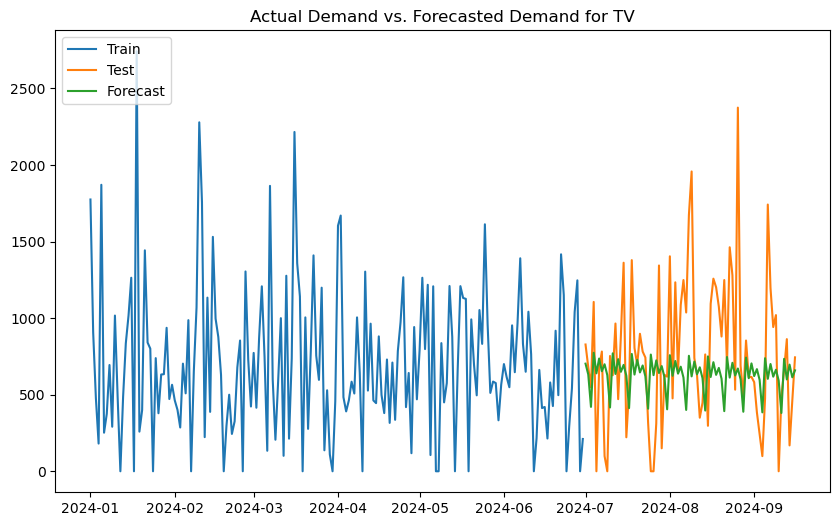

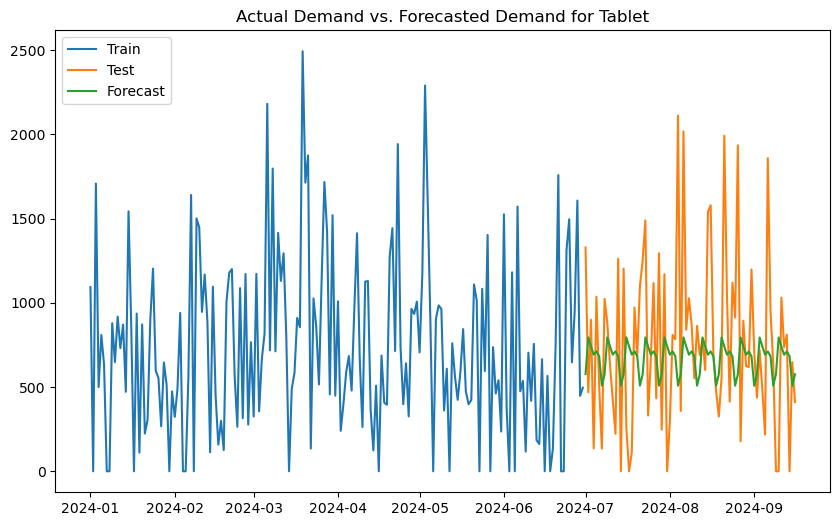

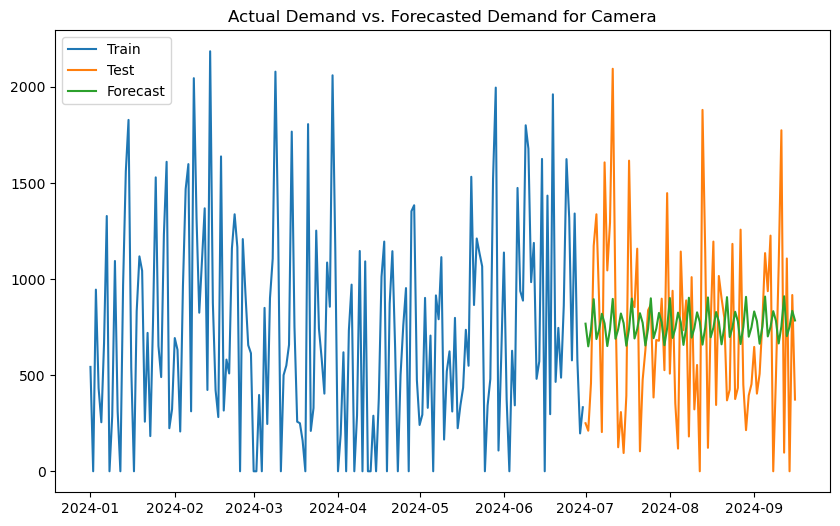

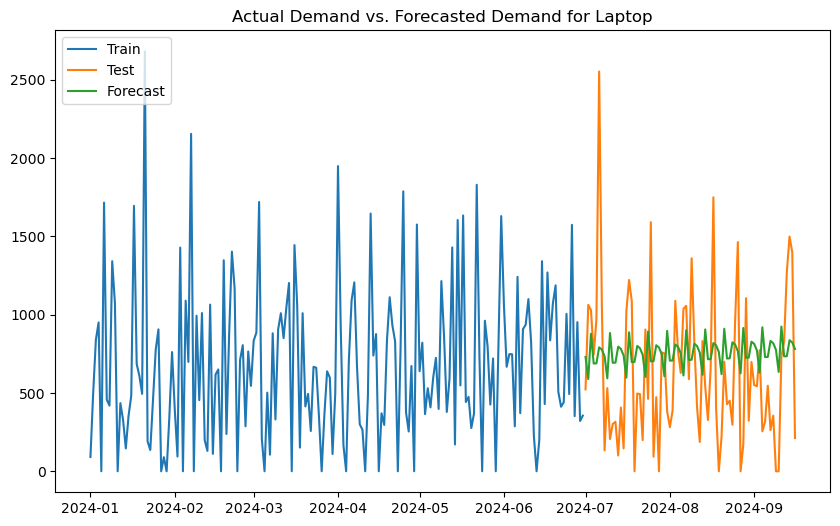

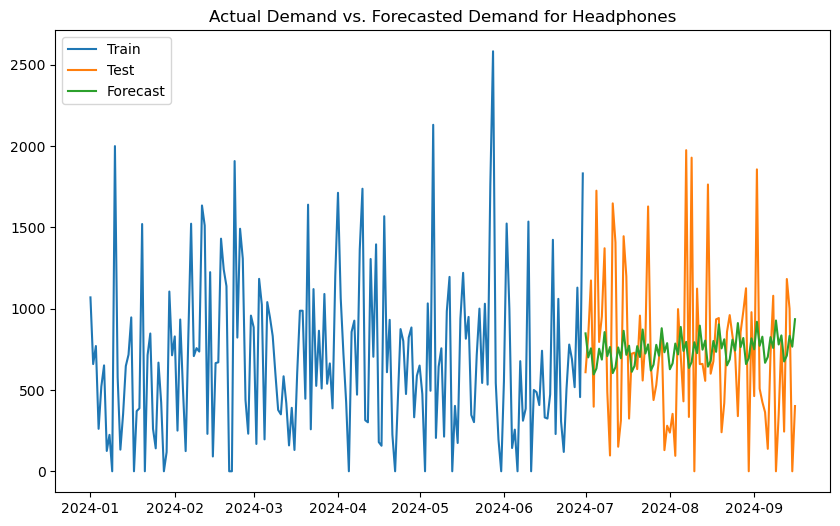

In [15]:
# %% ########  Data visualization ######################

items_graph = {
    "TV": (train_tv, test_tv, pred_triple_model_tv),
    "Tablet": (train_tab, test_tab, pred_triple_model_tab),
    "Camera": (train_cam, test_cam, pred_triple_model_cam),
    "Laptop": (train_laptop, test_laptop, pred_triple_model_laptop),
    "Headphones": (train_headphones, test_headphones,pred_triple_model_headphones)}

for item, (train, test, forecast) in items_graph.items():
    plt.figure(figsize=(10,6))
    plt.plot(train, label='Train')
    plt.plot(test, label='Test')
    plt.plot(forecast, label='Forecast')
    plt.legend(loc='upper left')
    plt.title(f'Actual Demand vs. Forecasted Demand for {item}')
    plt.show()

In [18]:
results = pd.DataFrame({
    "product_name": ["TV", "Tablet", "Camera", "Laptop", "Headphones"],
    "Smoothing Level": [
        fitted_model_tv.params.get("smoothing_level"),
        fitted_model_tab.params.get("smoothing_level"),
        fitted_model_cam.params.get("smoothing_level"),
        fitted_model_laptop.params.get("smoothing_level"),
        fitted_model_headphones.params.get("smoothing_level")
    ],
    "Smoothing Trend": [
        fitted_model_tv.params.get("smoothing_trend"),
        fitted_model_tab.params.get("smoothing_trend"),
        fitted_model_cam.params.get("smoothing_trend"),
        fitted_model_laptop.params.get("smoothing_trend"),
        fitted_model_headphones.params.get("smoothing_trend")
    ],
    "Smoothing Seasonal": [
        fitted_model_tv.params.get("smoothing_seasonal"),
        fitted_model_tab.params.get("smoothing_seasonal"),
        fitted_model_cam.params.get("smoothing_seasonal"),
        fitted_model_laptop.params.get("smoothing_seasonal"),
        fitted_model_headphones.params.get("smoothing_seasonal")
    ]
})

results

results.to_csv("HW_estimation_results.csv", index=False)

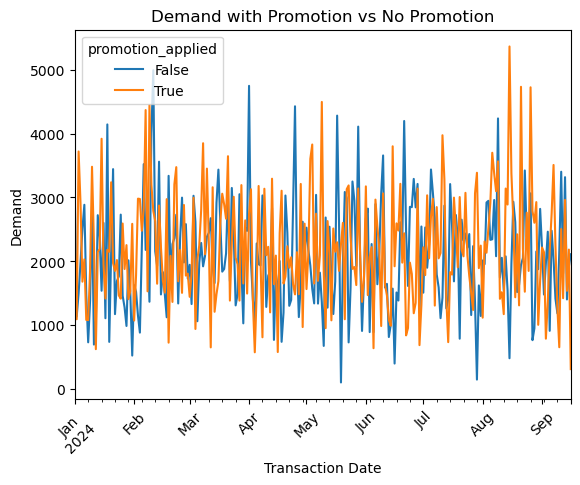

In [ ]:
# %%
# Demand with Promotion vs No Promotion
promo_affect = electronics.groupby(['transaction_date', 'promotion_applied'])['actual_demand'].sum().reset_index()
promo_linechart = promo_affect.pivot(index='transaction_date', columns='promotion_applied', values='actual_demand')

# transaction_date currently date objects; convert index to datetime for plotting
promo_linechart.index = pd.to_datetime(promo_linechart.index)

promo_linechart.plot()
plt.xticks(rotation=45)
plt.title("Demand with Promotion vs No Promotion")
plt.xlabel("Transaction Date")
plt.ylabel("Demand")
plt.show()

In [ ]:
# %%
# Optional: convert the original .py to .ipynb programmatically using nbformat or jupytext
# Using nbformat
try:
    import nbformat
    from nbformat.v4 import new_notebook, new_code_cell
    with open('Time Series Analysis.py', 'r') as f:
        src = f.read()
    nb = new_notebook(cells=[new_code_cell(src)])
    nbformat.write(nb, 'Time_Series_Analysis_from_py.ipynb')
    print('Wrote Time_Series_Analysis_from_py.ipynb')
except Exception as e:
    print('Could not convert automatically:', e)

# Or with jupytext (command-line):
# jupytext --to notebook "Time Series Analysis.py"

Could not convert automatically: [Errno 2] No such file or directory: 'Time Series Analysis.py'


Notes & Assumptions

- Weekly resampling was used (.resample('W').sum()).
- seasonal_periods=4 chosen due to partial-year data; with a full year you would typically use 52 for weekly seasonality.
- Models used: Holt-Winters Triple Exponential Smoothing (additive trend & seasonality).

Next steps

- Try seasonal_periods=52 if more data becomes available.
- Evaluate alternative models (SARIMA, Prophet, TBATS) and cross-validate.
- Add parameter tuning for smoothing_level/smoothing_slope/smoothing_seasonal and automated model selection.